<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-30 15:30:01--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.5’

survey-results-publ 100%[===================>] 201.62M  75.0MB/s    in 2.7s    

2026-01-30 15:30:06 (75.0 MB/s) - ‘survey-results-public.sqlite.5’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 141.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 162.7 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 153.4 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [8]:
# your code goes here
!pip install seaborn
import seaborn as sns


In [9]:
df = pd.read_csv('survey-data.csv')

df

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [10]:
df['Age'].describe()

count               65437
unique                  8
top       25-34 years old
freq                23911
Name: Age, dtype: object

In [11]:
df['Age'].info()

<class 'pandas.Series'>
RangeIndex: 65437 entries, 0 to 65436
Series name: Age
Non-Null Count  Dtype
--------------  -----
65437 non-null  str  
dtypes: str(1)
memory usage: 511.4 KB


In [12]:
df['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

In [13]:
q1 = df['CompTotal'].quantile(0.25)
q3 = df['CompTotal'].quantile(0.75)
IQR = q3 - q1
upper_bound = q3 + (1.5 * IQR)


Text(0.5, 0, 'Total Compensation')

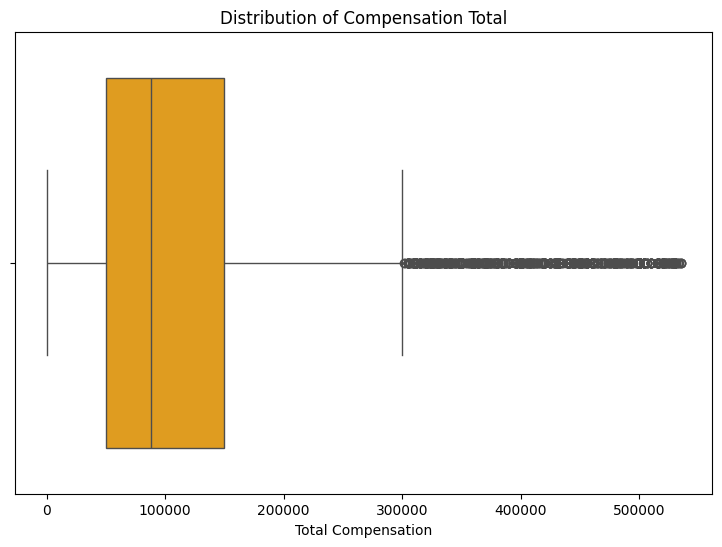

In [14]:
# df.columns
df_clean = df.dropna(subset = ['CompTotal'])
df_clean1 = df_clean[df_clean['CompTotal'] <= upper_bound]
plt.figure(figsize=(9,6))
sns.boxplot(data = df_clean1, x = 'CompTotal', color = 'orange')
plt.title('Distribution of Compensation Total')
plt.xlabel('Total Compensation')

Old Mean: 2.9638411381149976e+145
New Median (Best Metric): 107000.0
count    3.340200e+04
mean     1.052383e+06
std      5.950472e+06
min      0.000000e+00
25%      5.900250e+04
50%      1.070000e+05
75%      2.400000e+05
max      1.176000e+08
Name: CompTotal, dtype: float64


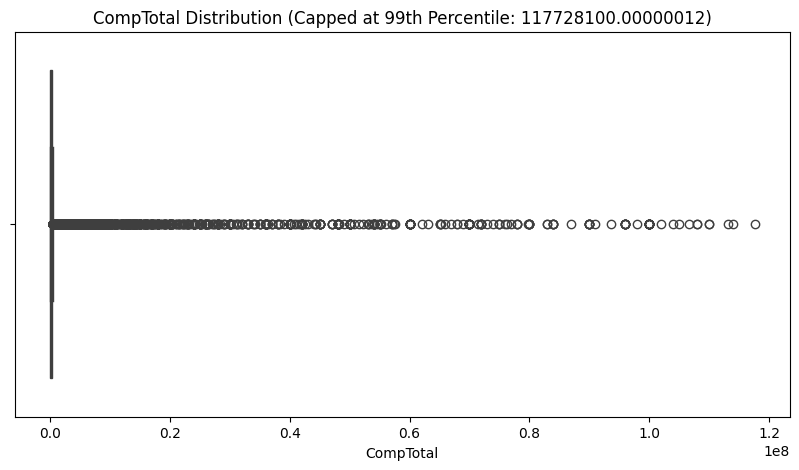

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop NaNs and calculate the 99th percentile threshold
df_clean = df.dropna(subset=['CompTotal'])
limit = df_clean['CompTotal'].quantile(0.99)

# 2. Filter data to remove the top 1% (including the 10^150 error)
df_filtered = df_clean[df_clean['CompTotal'] <= limit]

# 3. Recalculate Summary Statistics
print(f"Old Mean: {df_clean['CompTotal'].mean()}")
print(f"New Median (Best Metric): {df_filtered['CompTotal'].median()}")
print(df_filtered['CompTotal'].describe())

# 4. Generate the Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_filtered['CompTotal'])
plt.title(f'CompTotal Distribution (Capped at 99th Percentile: {limit})')
plt.show()


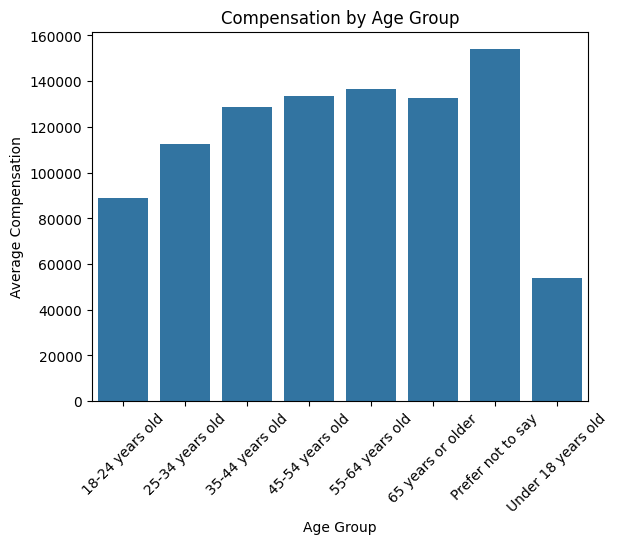

In [16]:
# df_age_comp =  df.groupby('Age')['CompTotal'].mean().reset_index()
# sns.barplot(data = df_age_comp, x = 'Age', y = 'CompTotal')
# plt.xlabel('Age Group')
# plt.ylabel('Average Compensation')
# plt.title('Compensation by Age Group')

# 1. Group and aggregate (this part is correct)
df_age_comp = df_clean1.groupby('Age')['CompTotal'].mean().reset_index()

# 2. Fix the barplot: Use ONLY column names as strings
sns.barplot(data=df_age_comp, x='Age', y='CompTotal')

# 3. Labeling
plt.xlabel('Age Group')
plt.ylabel('Average Compensation')
plt.title('Compensation by Age Group')
plt.xticks(rotation = 45)
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [17]:
# your code goes here
df['Age'].info()
# df['Age'] = pd.to_numeric(df['Age'],errors='coerce')
# df_nan = df['Age'].isnull().sum()
# df_nan
print(df['Age'].unique())

<class 'pandas.Series'>
RangeIndex: 65437 entries, 0 to 65436
Series name: Age
Non-Null Count  Dtype
--------------  -----
65437 non-null  str  
dtypes: str(1)
memory usage: 511.4 KB
<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str


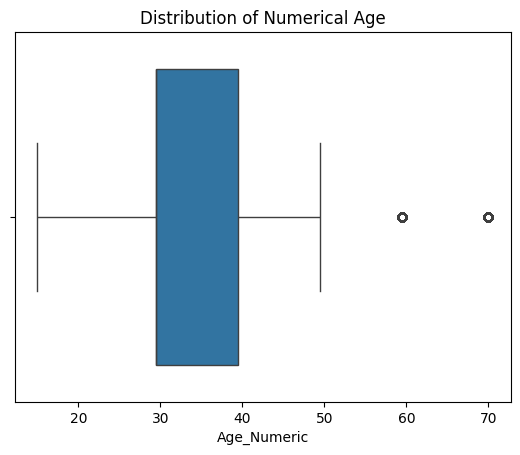

In [18]:
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['Age_Numeric'] = df_clean1['Age'].map(age_map)

import seaborn as sns
import matplotlib.pyplot as plt

# Plotting numeric age vs compensation
sns.boxplot(data=df, x='Age_Numeric') #, y='CompTotal')

plt.title('Distribution of Numerical Age')
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [19]:
print(df[['Age', 'CompTotal']].info())

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        65437 non-null  str    
 1   CompTotal  33740 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1022.6 KB
None


                  Age      CompTotal
0     18-24 years old   1.725626e+24
1     25-34 years old  6.822679e+145
2     35-44 years old   1.069290e+61
3     45-54 years old   5.076824e+06
4     55-64 years old   7.818608e+49
5   65 years or older   2.053740e+05
6   Prefer not to say   1.539501e+05
7  Under 18 years old   2.307812e+07


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '25-34 years old'),
  Text(1, 0, '35-44 years old'),
  Text(2, 0, '45-54 years old'),
  Text(3, 0, '55-64 years old'),
  Text(4, 0, '18-24 years old'),
  Text(5, 0, '65 years or older'),
  Text(6, 0, 'Under 18 years old'),
  Text(7, 0, 'Prefer not to say')])

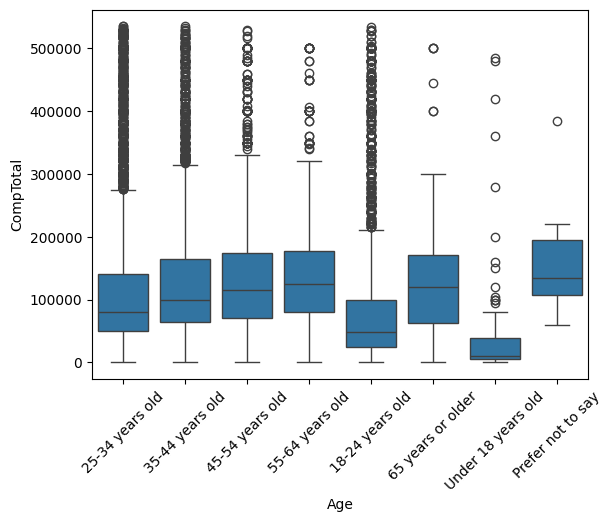

In [33]:
# your code goes here
# df_age_group = df['CompTotal'].groupby(df['Age'])
# df_age_group
print(df.groupby('Age')['CompTotal'].mean().reset_index())

sns.boxplot(data = df_clean1, x = 'Age', y = 'CompTotal')
plt.xticks(rotation = 45)

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [27]:
df['JobSatPoints_6'].isnull().sum()
df_jobsat6_clean = df['JobSatPoints_6'].dropna()
df_jobsat6_clean.shape 

(29450,)

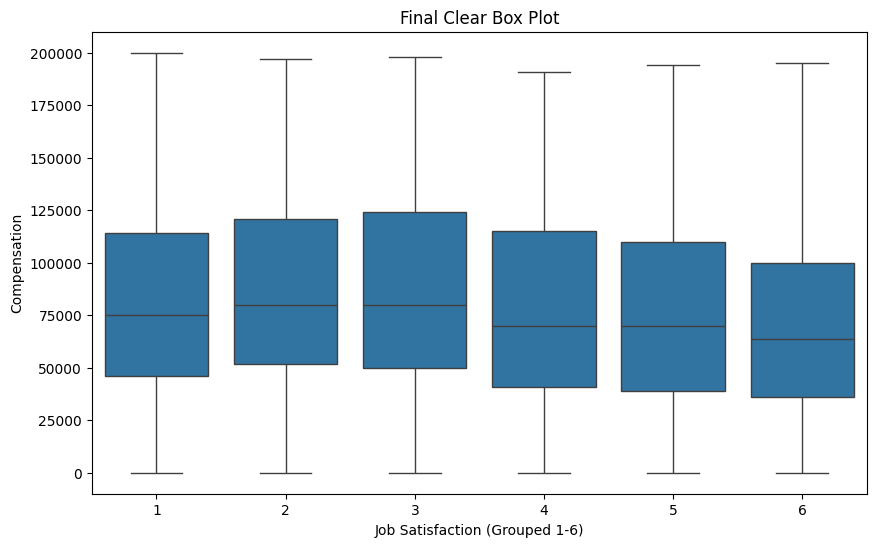

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CompTotal ko numeric banayein aur outliers hatayein (taki messy na dikhe)
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df_clean = df[df['CompTotal'] < 200000].copy()

# 2. 95 unique values ko 6 saaf bins mein convert karein
# Ye aapke 0-100 ya jo bhi range hai usse 6 barabar hisso mein baant dega
df_clean['JobSat_Groups'] = pd.cut(df_clean['JobSatPoints_6'], bins=6, labels=[1, 2, 3, 4, 5, 6])

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='JobSat_Groups', y='CompTotal')

plt.xlabel('Job Satisfaction (Grouped 1-6)')
plt.ylabel('Compensation')
plt.title('Final Clear Box Plot')
plt.show()


In [48]:
df_final['JobSatPoints_6'].unique()

array([  0,  20,  30,  25,  50,  10,   5,  15,  18,  40,  35,  80, 100,
        90,  45,  34,  16,  70,  85,  60,   1,   9,  14,  31,  12,  23,
        28,  75,   8,  81,   6,  13,  65,  55,   7,  33,  11,  36,   3,
        27,  17,  95,  99,  21,  24,  19,  22,   4,  29,   2,  37,  77,
        68,  32,  66,  82,  61,  26,  88,  43,  69,  87,  73,  46,  49,
        52,  97,  96,  67,  86,  56,  41,  98,  51,  76,  48,  64,  54,
        78,  63])

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [53]:
# Count each developer type (handling multiple values per row)
top_5_types = df['DevType'].str.split(';').explode().value_counts().head(5).index.tolist()
top_5_types

['Developer, full-stack',
 'Developer, back-end',
 'Student',
 'Developer, front-end',
 'Developer, desktop or enterprise applications']

In [54]:
# Filter the dataframe to include ONLY these top 5 types
df_top5 = df[df['DevType'].isin(top_5_types)].copy()
df_top5

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Numeric
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65413,65414,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Social Media;How-to videos;Video-based Online ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65417,65418,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Coding Bootcamp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65428,65429,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Other online ...,Technical documentation;Books;Interactive tuto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65431,65432,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.5


In [ ]:
df_top5['ConvertedCompYearly'] = pd.to_numeric(df_top5['ConvertedCompYearly'], errors='coerce')

# Keep data below a certain limit to make the plot readable
df_final = df_top5[df_top5['ConvertedCompYearly'] < 250000]


/tmp/ipykernel_301/2064946547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='DevType', y='ConvertedCompYearly', palette='Set3', order=top_5_types)


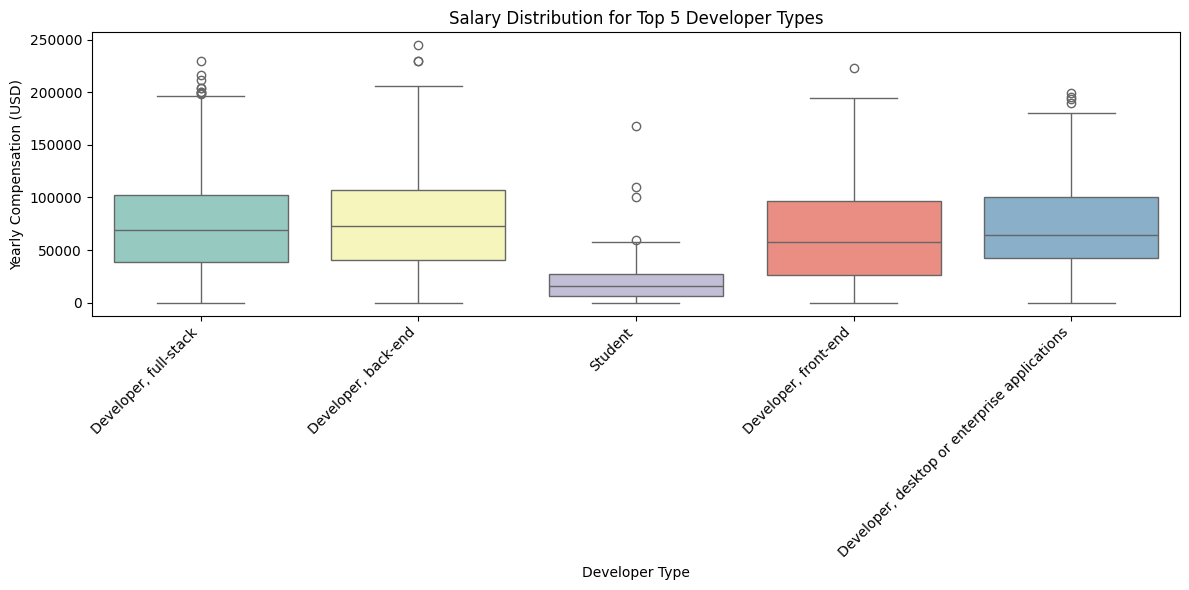

In [59]:
# your code goes here
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final, x='DevType', y='ConvertedCompYearly', palette='Set3', order=top_5_types)
# order = top_5_types orderd top 5 values by seaborn and shown only that 5 categories on that base the graph was prepared .. 
# Improve readability
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Yearly Compensation (USD)')
plt.tight_layout()

plt.show()


**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [61]:
# your code goes here
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify the Top 5 Countries by response count
top_5_countries = df['Country'].value_counts().head(5).index.tolist()
top_5_countries 

['United States of America',
 'Germany',
 'India',
 'United Kingdom of Great Britain and Northern Ireland',
 'Ukraine']

In [62]:
# 2. Filter the DataFrame for only these 5 countries
df_top5_countries = df[df['Country'].isin(top_5_countries)].copy()

In [63]:
# 3. Clean Compensation data
df_top5_countries['CompTotal'] = pd.to_numeric(df_top5_countries['CompTotal'], errors='coerce')


In [64]:
# 4. Remove outliers (keeping only values below 250k for a clear view)
df_plot = df_top5_countries[df_top5_countries['CompTotal'] < 250000]


/tmp/ipykernel_301/223673345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Country', y='CompTotal', order=top_5_countries, palette='Set2')


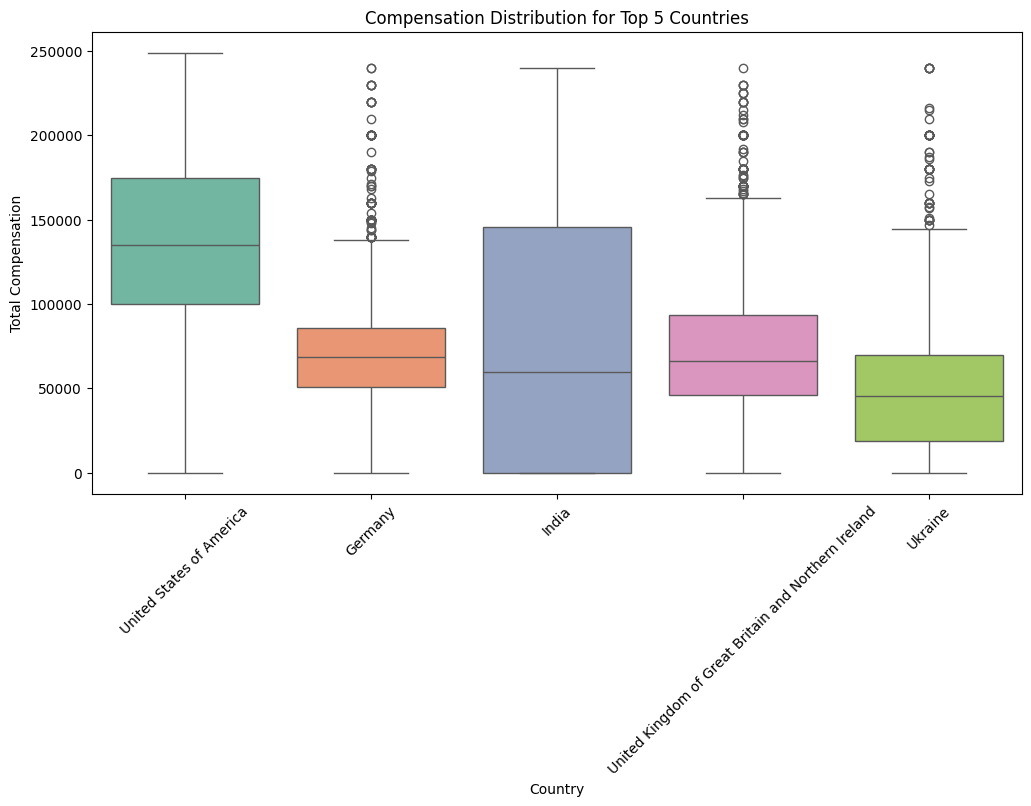

In [65]:
# 5. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Country', y='CompTotal', order=top_5_countries, palette='Set2')

plt.title('Compensation Distribution for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/tmp/ipykernel_301/3140623583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Employment_Clean', y='CompTotal', palette='pastel')


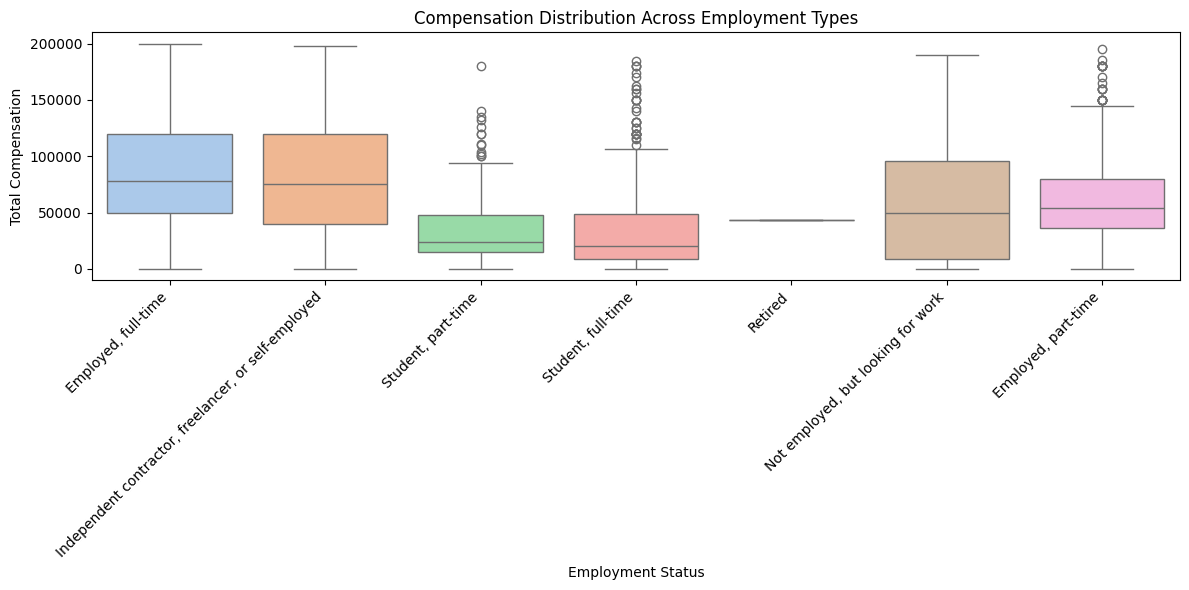

In [66]:
# your code goes here
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Handle Multi-choice: Keep only the first employment type listed for clarity
# This prevents labels like "Full-time;Part-time" from creating extra boxes
df['Employment_Clean'] = df['Employment'].str.split(';').str[0]

# 2. Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 3. Filter Outliers: Keep only reasonable salary ranges (e.g., < 200k)
# Without this, the boxes will look like flat lines due to extreme values
df_plot = df[df['CompTotal'] < 200000].copy()

# 4. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Employment_Clean', y='CompTotal', palette='pastel')

# 5. Formatting
plt.xticks(rotation=45, ha='right')
plt.title('Compensation Distribution Across Employment Types')
plt.xlabel('Employment Status')
plt.ylabel('Total Compensation')
plt.tight_layout()

plt.show()


**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


/tmp/ipykernel_301/2682992859.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='JobSatPoints_6', y='YearsCodePro', palette='coolwarm')


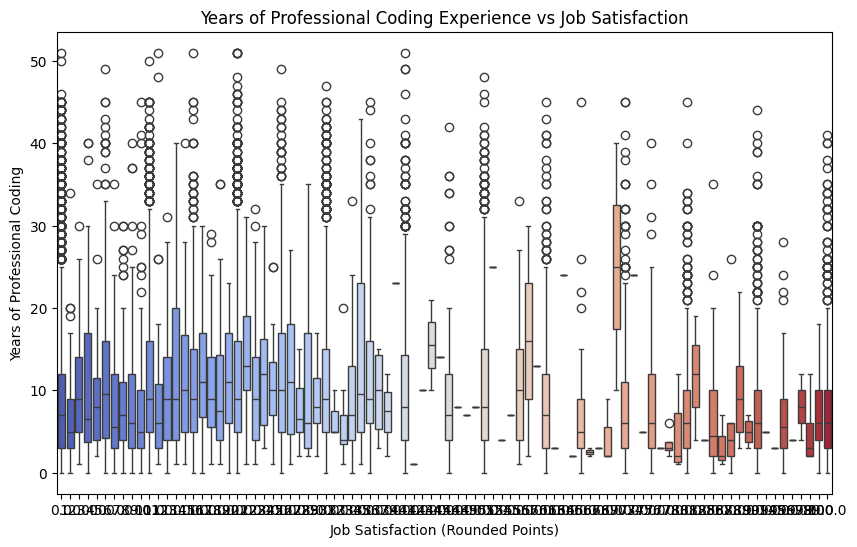

In [67]:
# your code goes here
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean YearsCodePro: Handle strings like 'Less than 1 year' or 'More than 50 years'
# We replace text with numbers so it becomes a numeric column
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# 2. Clean Job Satisfaction: Round values to avoid 100+ messy boxes
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce').round()
# Remove rows where satisfaction is missing
df_clean = df.dropna(subset=['JobSatPoints_6', 'YearsCodePro']).copy()

# 3. Create the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='JobSatPoints_6', y='YearsCodePro', palette='coolwarm')

# 4. Labeling
plt.title('Years of Professional Coding Experience vs Job Satisfaction')
plt.xlabel('Job Satisfaction (Rounded Points)')
plt.ylabel('Years of Professional Coding')
plt.show()


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
